#Modelo - MobileNet

##Importar Bibliotecas

In [1]:
# bibliotecas
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array

##Carregar Dataset e visualizar alguns dados exemplo

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
# unzip do dataset
!unzip /content/drive/MyDrive/Dataset_turma.zip

Archive:  /content/drive/MyDrive/Dataset_turma.zip
   creating: dataset/
   creating: dataset/test/
   creating: dataset/test/banana/
  inflating: dataset/test/banana/20241119_132606.jpg  
  inflating: dataset/test/banana/20241119_132636.jpg  
  inflating: dataset/test/banana/20241119_132947.jpg  
  inflating: dataset/test/banana/20241119_132951.jpg  
  inflating: dataset/test/banana/20241119_133152.jpg  
  inflating: dataset/test/banana/20241119_133452.jpg  
  inflating: dataset/test/banana/20241119_133525.jpg  
  inflating: dataset/test/banana/20241125_232906.jpg  
  inflating: dataset/test/banana/20241125_232929.jpg  
  inflating: dataset/test/banana/20241125_232957.jpg  
  inflating: dataset/test/banana/IMG_0480_jpg.rf.2b62bd414fa21e137abbe170722dc38b.jpg  
  inflating: dataset/test/banana/IMG_0655_jpg.rf.8b4afee1d0b99cca073e6a35a52377e7.jpg  
  inflating: dataset/test/banana/IMG_0759_jpg.rf.fe0f0ca4d681df48b7226e44e5703d2e.jpg  
  inflating: dataset/test/banana/IMG_20241123_162420

In [6]:
input_size = (320, 320)

# carregar imagens
train_set = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/dataset/train",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

val_set = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/dataset/valid/",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

test_set = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/dataset/test/",
    seed=1337,
    image_size=input_size,
    label_mode='categorical'
)

# classes
class_names = train_set.class_names

NotFoundError: Could not find directory /content/dataset/dataset/train

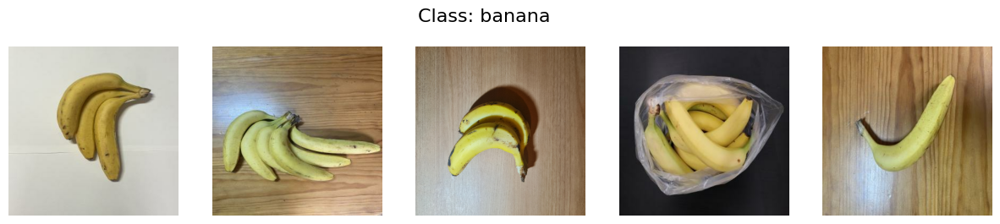

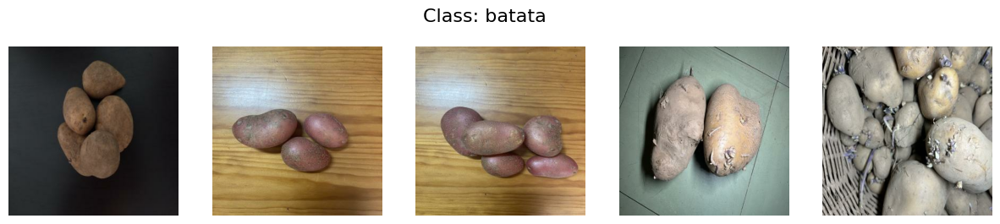

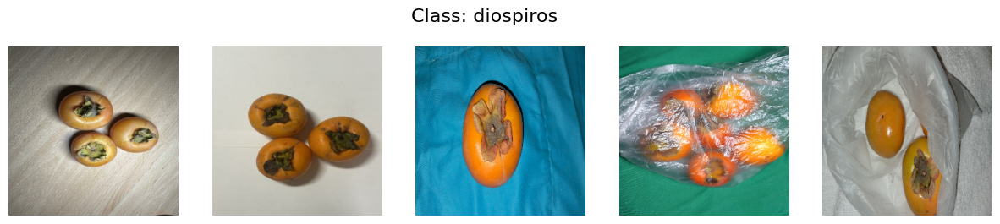

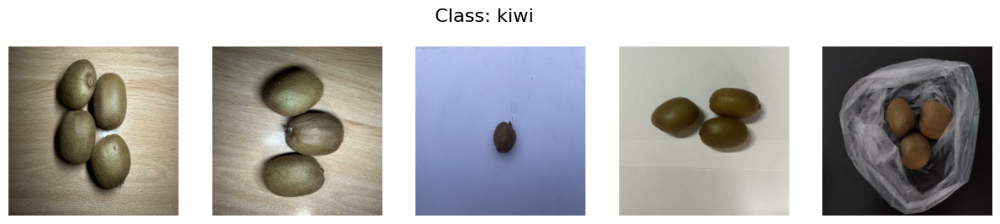

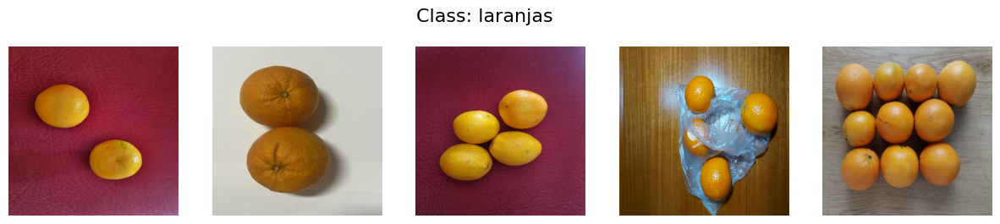

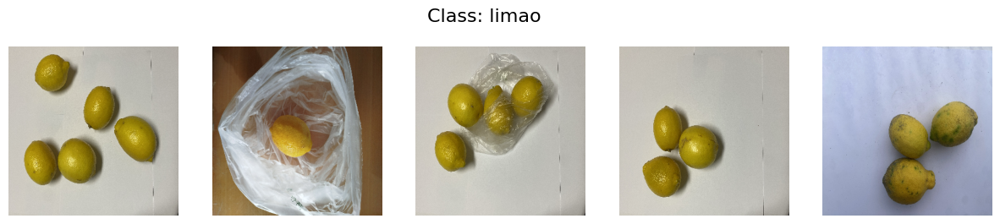

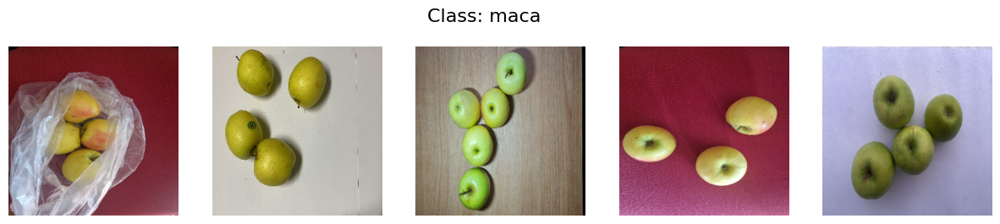

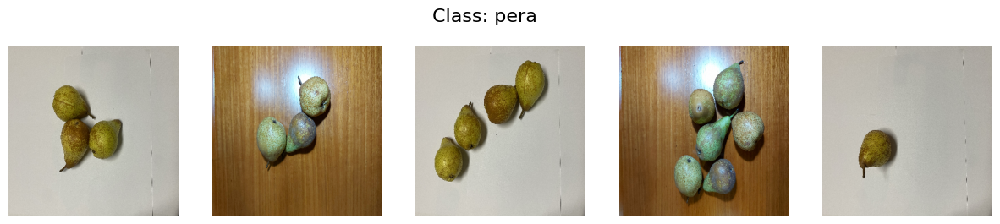

In [ ]:
images_by_class = {class_name: [] for class_name in class_names}

for images, labels in train_set.take(-1):
    images_np = images.numpy().astype("uint8")
    labels_np = labels.numpy()

    for img, label in zip(images_np, labels_np):
        class_idx = tf.argmax(label).numpy()
        class_name = class_names[class_idx]

        if len(images_by_class[class_name]) < 5:
            images_by_class[class_name].append(img)

    if all(len(img_list) == 5 for img_list in images_by_class.values()):
        break

for class_name, images in images_by_class.items():
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {class_name}", fontsize=16)
    for i, img in enumerate(images):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

In [ ]:
# normalização das imagens
train_set = train_set.map(lambda x, y: (x / 255.0, y))
val_set = val_set.map(lambda x, y: (x / 255.0, y))
test_set = test_set.map(lambda x, y: (x / 255.0, y))

In [ ]:
# inicializar modelo
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False  # congelar o modelo

# adicionar uma nova layer de saída ao modelo, para classificar as classes corretas
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(8, activation='softmax')  # 2 classes
])

# compilar modelo
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

<ipython-input-7-403025e8ae0d>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(320, 320, 3))


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Early stopping callback para parar o treino quando não existe melhoria da validation loss
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,               # pára o treino após 5 épocas
    restore_best_weights=True # reverter os pesos do treino para os melhores obtidos
)

# Reduce learning rate callback para atualizar o learning rate quando não existe melhoria da validation loss
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,               # reduzir learning rate por um fator de 0.1
    patience=3,               # atualiza após 3 épocas
    min_lr=1e-10              # learning rate mínimo
)

model_checkpoint = ModelCheckpoint('/content/model_checkpoint.keras', save_best_only=True, monitor='val_loss', mode='min'),


In [ ]:
# treinar o modelo
history = model.fit(train_set,
                    batch_size = 32,
                    epochs=50,
                    validation_data=val_set,
                    callbacks=[early_stopping, reduce_lr, model_checkpoint])


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 163s 6s/step - accuracy: 0.1747 - loss: 2.2425 - val_accuracy: 0.2375 - val_loss: 2.0010 - learning_rate: 1.0000e-04
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 108s 4s/step - accuracy: 0.2482 - loss: 1.9920 - val_accuracy: 0.3500 - val_loss: 1.8002 - learning_rate: 1.0000e-04
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 102s 4s/step - accuracy: 0.3800 - loss: 1.7583 - val_accuracy: 0.4225 - val_loss: 1.6364 - learning_rate: 1.0000e-04
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.4622 - loss: 1.6112 - val_accuracy: 0.5325 - val_loss: 1.4926 - learning_rate: 1.0000e-04
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.5565 - loss: 1.4687 - val_accuracy: 0.5875 - val_loss: 1.3672 - learning_rate: 1.0000e-04
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.6487 - loss: 1.3157 - val_accuracy: 0.6350 - val_loss: 1.2585 - learning_rate: 1.0000e-04
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.6798 -

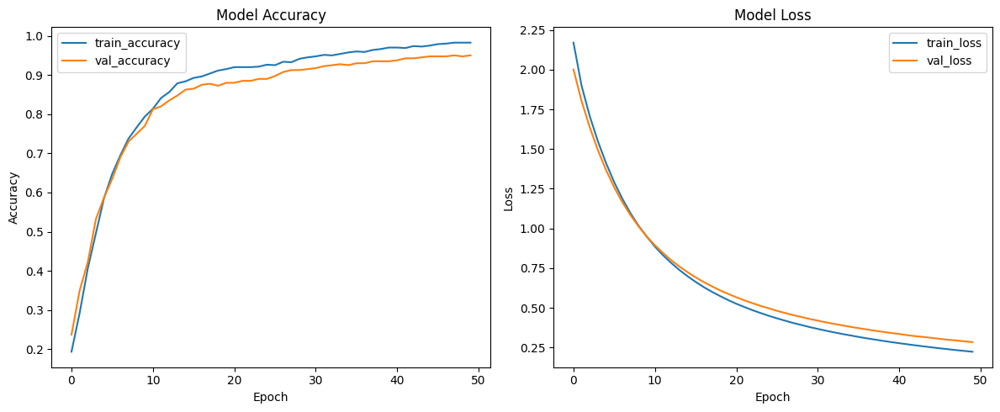

In [ ]:
# criar figura
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='train_accuracy')
axes[0].plot(history.history['val_accuracy'], label='val_accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_title('Model Accuracy')

# Loss plot
axes[1].plot(history.history['loss'], label='train_loss')
axes[1].plot(history.history['val_loss'], label='val_loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_title('Model Loss')

plt.tight_layout()
plt.show()

In [ ]:
# avaliar treino com base nos dados de teste
test_loss, test_accuracy = model.evaluate(test_set)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9389 - loss: 0.2853
Test accuracy: 94.17%


In [ ]:
def test_confusion_matrix(model, test_set, class_names):

    # labels e previsões
    y_true = []
    y_pred = []

    for images, labels in test_set:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))  # Previsão da classe


        if labels.shape[-1] > 1:
            y_true.extend(np.argmax(labels, axis=1))
        else:
            y_true.extend(labels.numpy())

    # lista para array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Generate classification report
    print("\n Relatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # matrix de confusão
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Matriz de Confusão")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

 Relatório de Classificação:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        30
      batata       0.97      1.00      0.98        30
   diospiros       1.00      0.97      0.98        30
        kiwi       0.92      0.77      0.84        30
    laranjas       0.94      1.00      0.97        30
       limao       0.90      0.93      0.92        30
        maca       0.97      0.93      0.95        30
        pera       0.85      0.93      0.89        30

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240



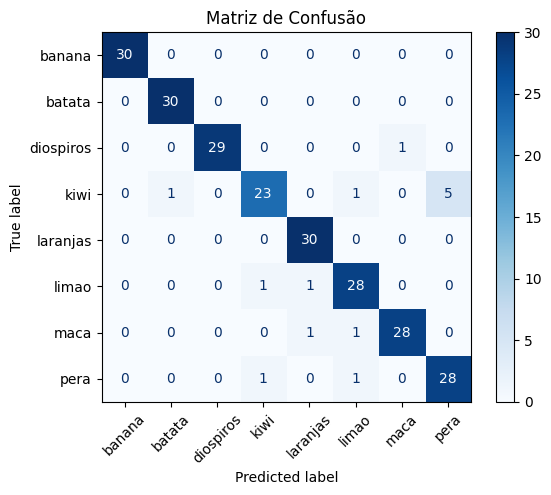

In [ ]:
test_confusion_matrix(model, test_set, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Total de imagens incorretamente classificadas: 14


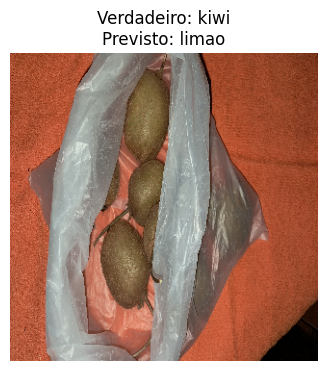

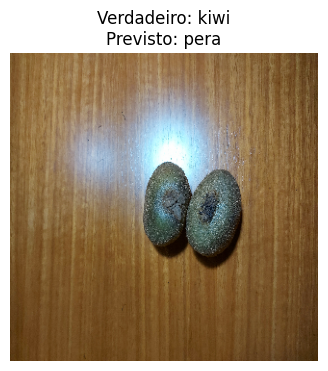

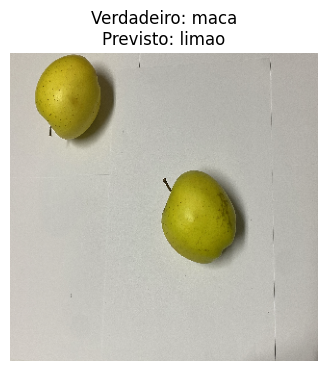

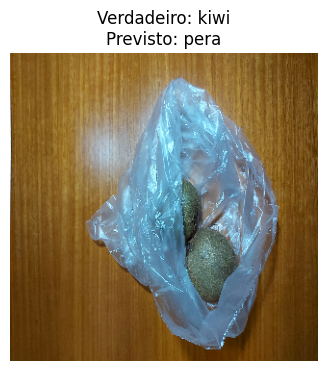

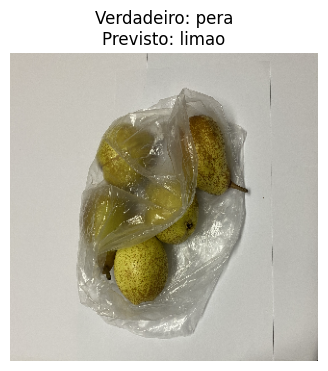

...

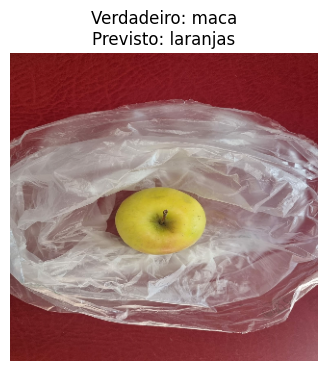

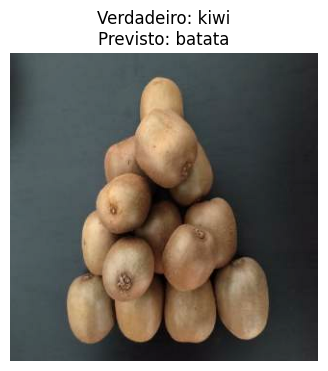

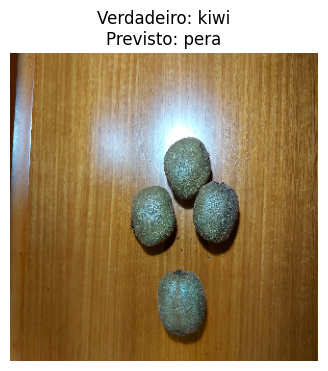

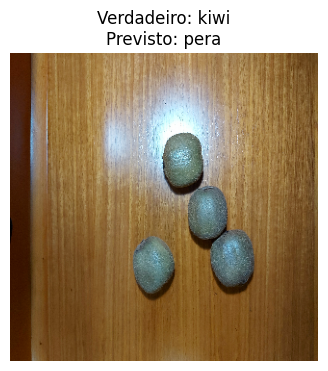

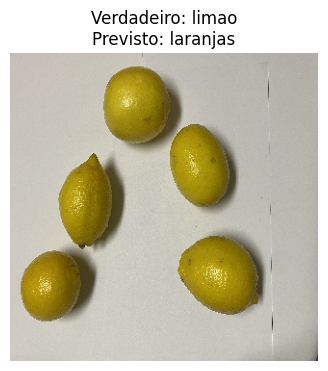

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import array_to_img

def display_misclassified_images(model, test_set, class_names):
    """
    Exibe as imagens que foram incorretamente classificadas pelo modelo, junto com os caminhos.

    Args:
        model: Modelo treinado para fazer previsões.
        test_set: Conjunto de dados de teste.
        class_names: Lista com os nomes das classes.
    """
    y_true = []
    y_pred = []
    misclassified_images = []

    for images, labels in test_set:
        predictions = model.predict(images)
        predicted_classes = np.argmax(predictions, axis=1)  # Classes previstas

        if labels.shape[-1] > 1:
            true_classes = np.argmax(labels.numpy(), axis=1)  # Classes reais (categorical)
        else:
            true_classes = labels.numpy()  # Classes reais (sparse)

        # Identificar erros de classificação
        for i in range(len(images)):
            if predicted_classes[i] != true_classes[i]:
                misclassified_images.append({
                    "image": images[i],
                    "true_label": class_names[true_classes[i]],
                    "predicted_label": class_names[predicted_classes[i]]
                })

    # Exibir as imagens incorretamente classificadas
    print(f"Total de imagens incorretamente classificadas: {len(misclassified_images)}")

    for idx, item in enumerate(misclassified_images):
        plt.figure(figsize=(4, 4))
        plt.imshow(array_to_img(item["image"]))
        plt.title(f"Verdadeiro: {item['true_label']}\nPrevisto: {item['predicted_label']}")
        plt.axis("off")
        plt.show()

# Exemplo de uso (após definir test_set e class_names)
display_misclassified_images(model, test_set, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


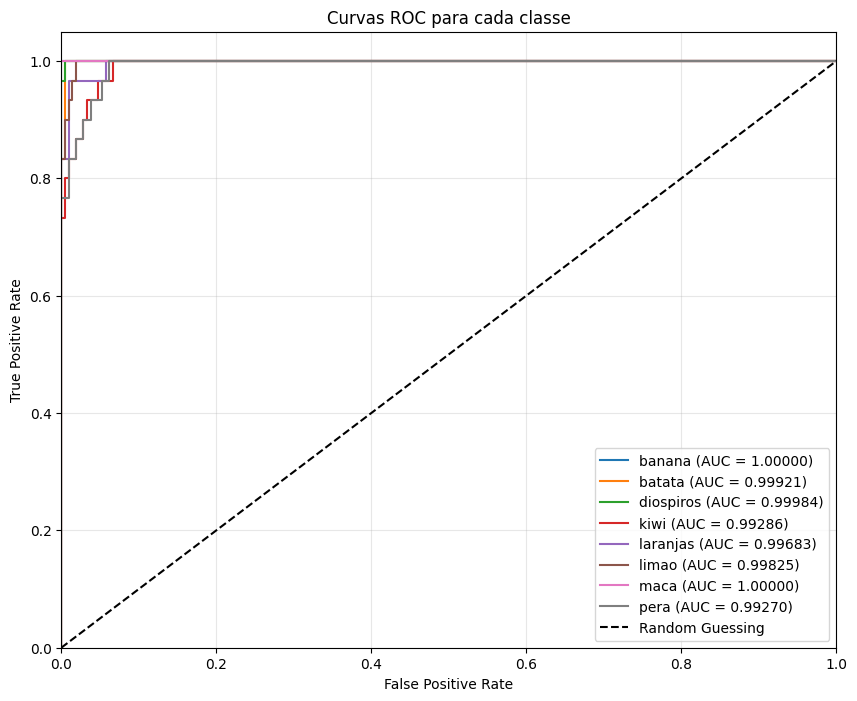

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

#Obter previsões para o conjunto de teste
y_true = []
y_pred_proba = []

for images, labels in test_set:
    predictions = model.predict(images)
    y_pred_proba.extend(predictions)  # Probabilidades preditas
    y_true.extend(labels.numpy())     # Labels reais

#Converter listas para arrays
y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)

#Binarizar os rótulos se necessário
if y_true.shape[1] != len(class_names):
    y_true = label_binarize(y_true, classes=range(len(class_names)))

#Plotar as curvas ROC para cada classe
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, thresholds = roc_curve(y_true[:, i], y_pred_proba[:, i])
    #fpr, tpr,  = roc_curve(y_true[:, i], y_pred_proba[:, i])  # FPR e TPR
    roc_auc = auc(fpr, tpr)  # Área sob a curva

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.5f})')

#Configurar o gráfico
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')  # Linha de referência
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC para cada classe')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# utilizando keras é necessário compilar o modelo antes de carregar os pesos
# o modelo tem de ser exatamente o mesmo

# inicializar modelo
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False  # congelar o modelo

# adicionar uma nova layer de saída ao modelo, para classificar as classes corretas
model_load_weights = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(8, activation='softmax')  # 2 classes
])

# compilar modelo
model_load_weights.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_load_weights.build(input_shape=(None, 320, 320, 3))

# carregar pesos
model_load_weights.load_weights("/content/model_checkpoint.keras")

<ipython-input-16-6006cfa8f4a0>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=75f08425383429cd2c8e9ab84164caf682b7995e29754441d71f1ad5212fd1a6
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted class: limao with confidence: 39.94%


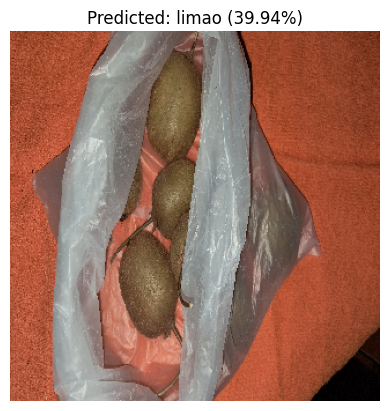

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/kiwi/20241125_141727.jpg"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━

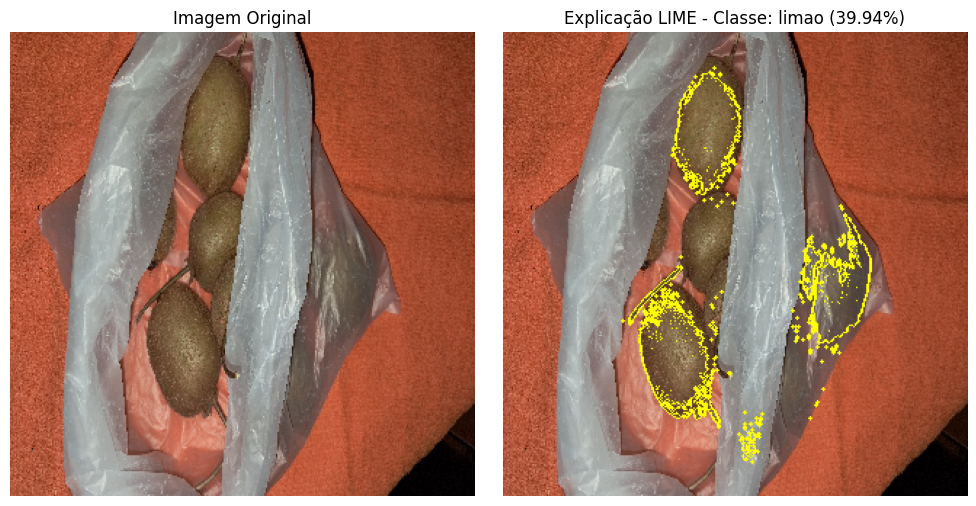

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/kiwi/20241125_141727.jpg"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted class: limao with confidence: 50.27%


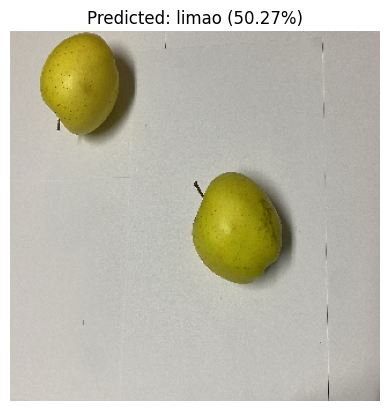

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/maca/IMG_3548.png"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

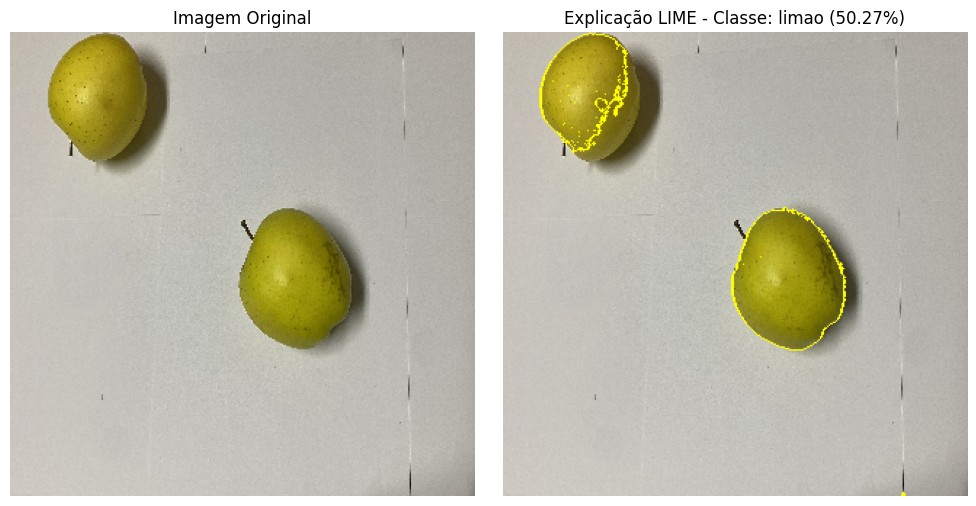

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/maca/IMG_3548.png"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted class: batata with confidence: 59.37%


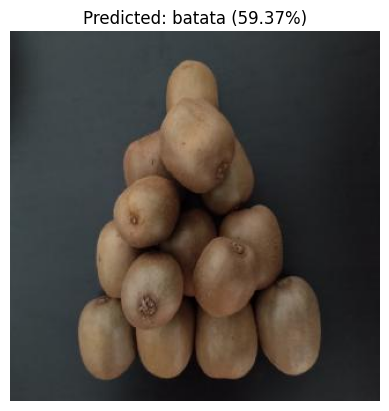

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/kiwi/IMG_20241124_122953_edit_27756039686962_jpg.rf.899f4ebf9edfd8e947729a7ef6e9eb41.jpg"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


ValueError: The layer sequential has never been called and thus has no defined output.

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━

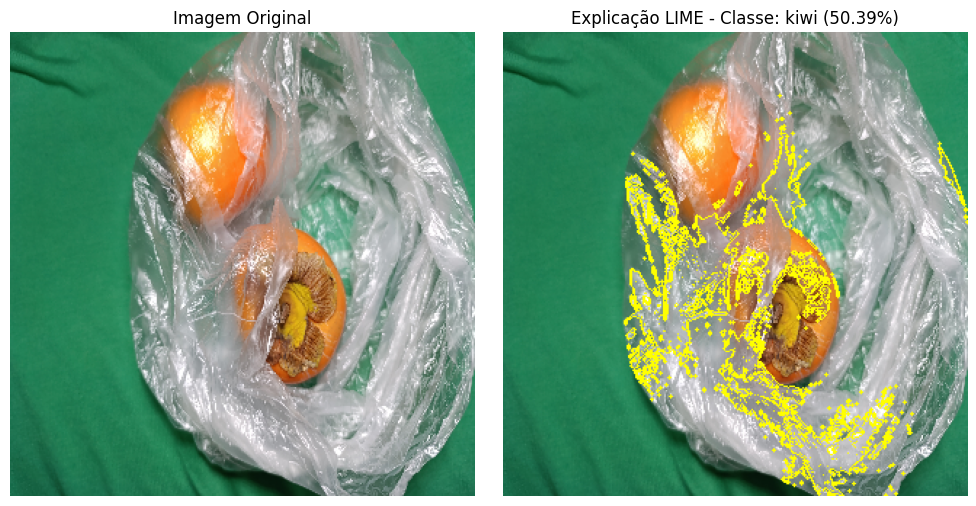

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/diospiros/1732399837497.jpg"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted class: laranjas with confidence: 40.13%


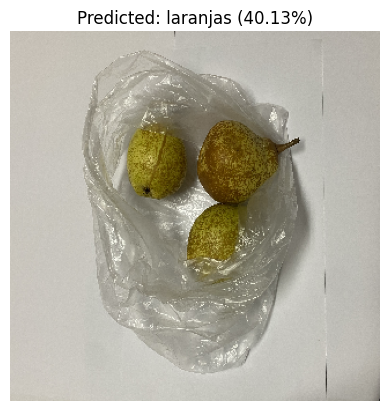

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/pera/IMG_3406.png"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━

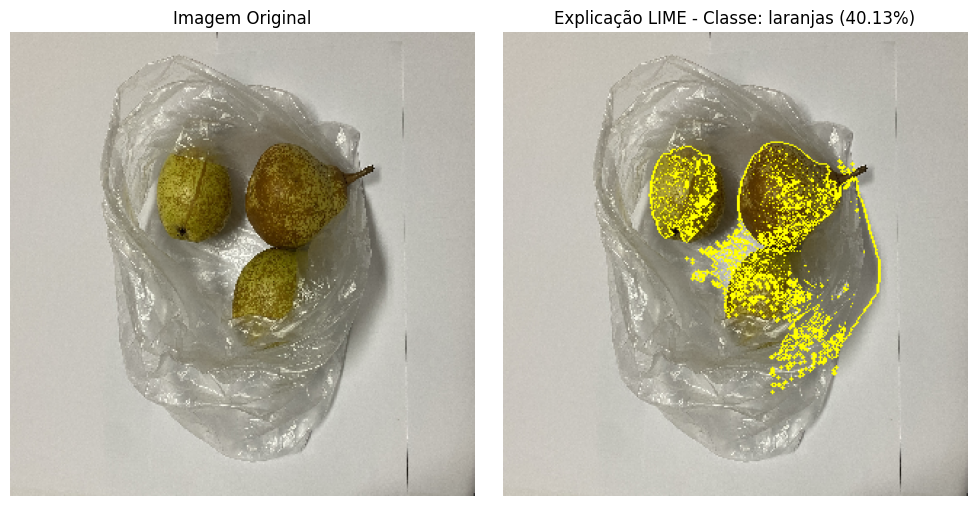

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/pera/IMG_3406.png"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted class: maca with confidence: 41.02%


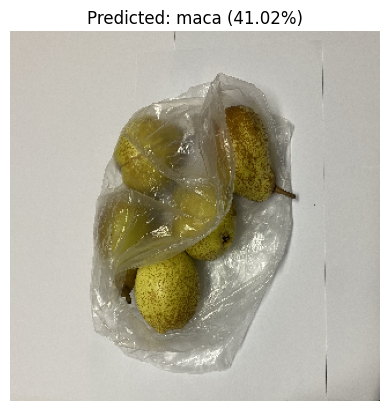

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/pera/IMG_3412.png"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━

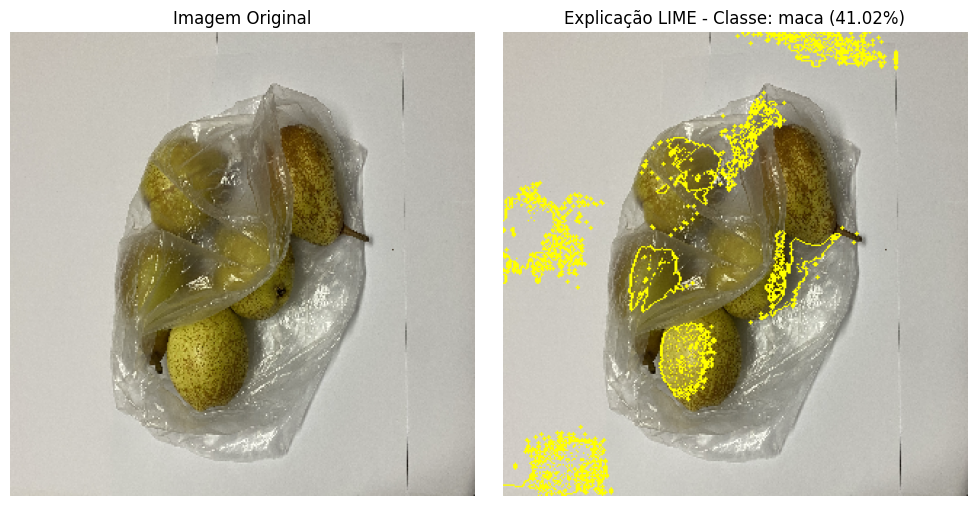

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/pera/IMG_3412.png"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Predicted class: maca with confidence: 50.85%


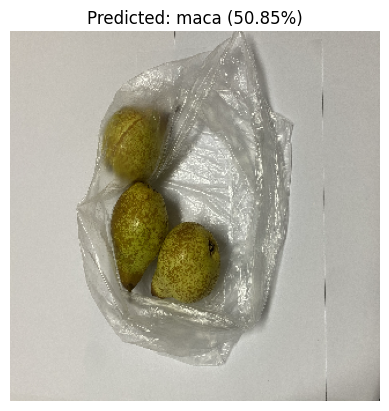

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/pera/IMG_3415.png"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━

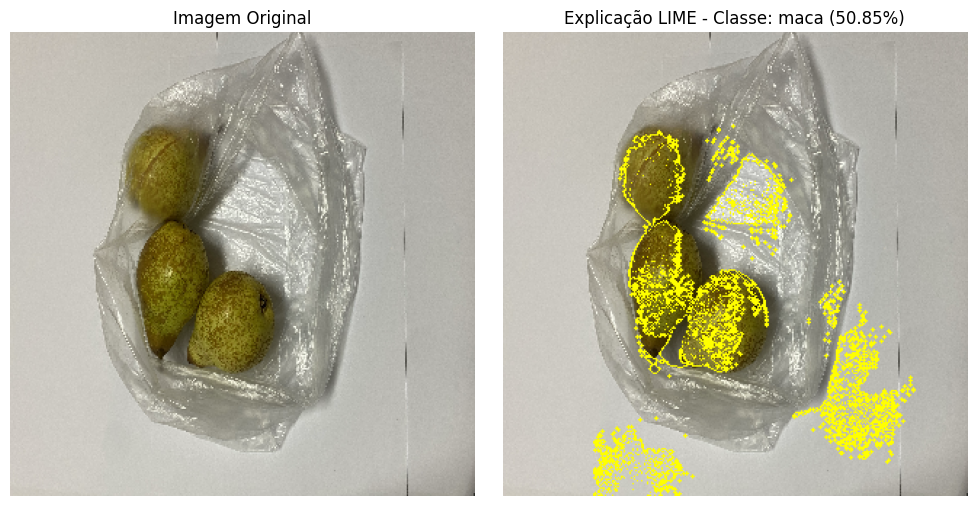

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/pera/IMG_3415.png"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted class: batatas with confidence: 56.12%


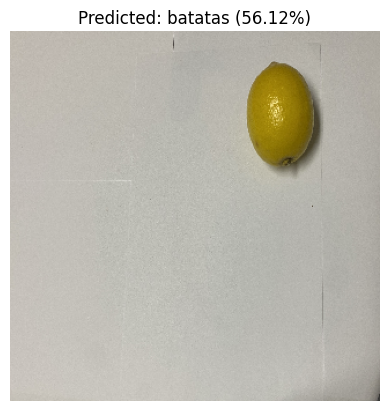

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/limao/IMG_3427.png"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━

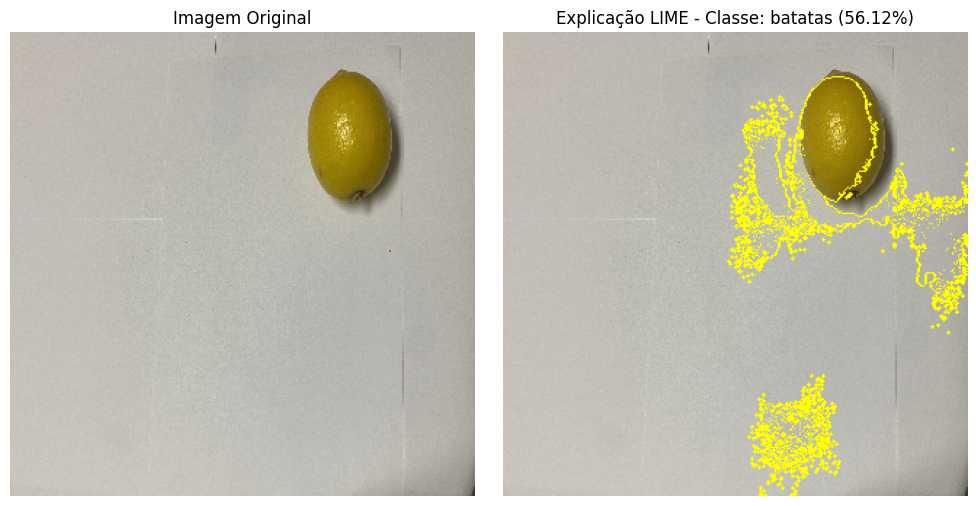

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/limao/IMG_3427.png"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted class: batatas with confidence: 65.92%


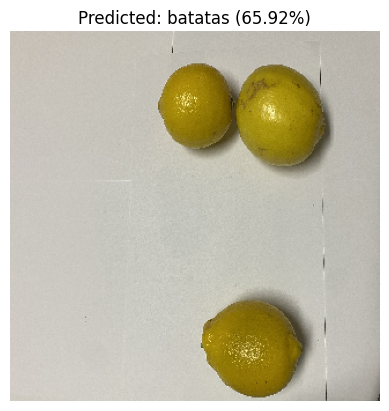

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/limao/IMG_3455.png"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━

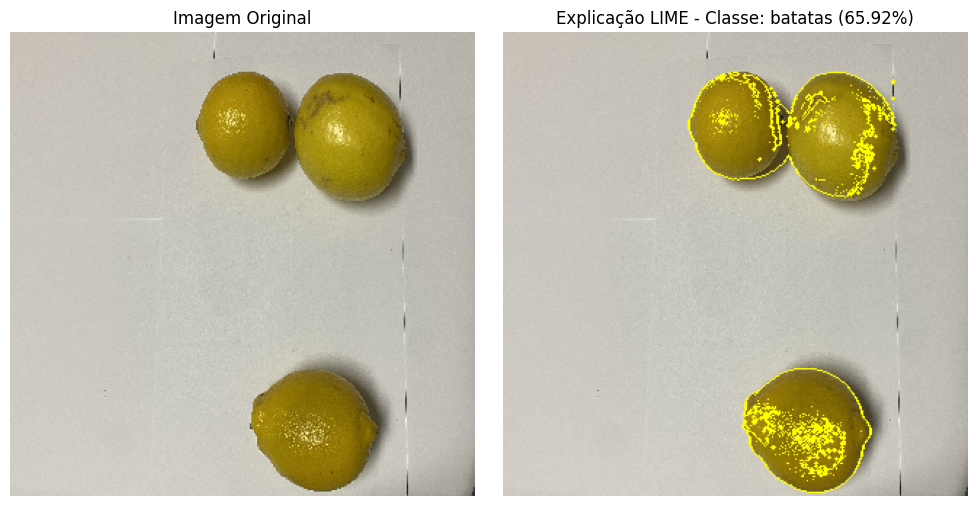

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/limao/IMG_3455.png"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted class: batatas with confidence: 88.93%


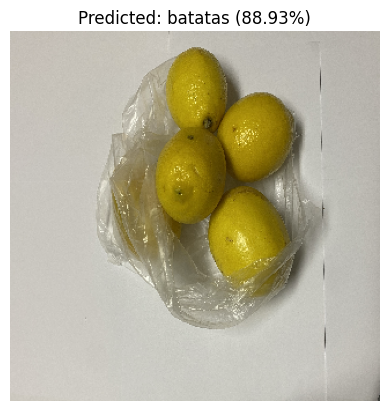

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/limao/IMG_3495.png"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━

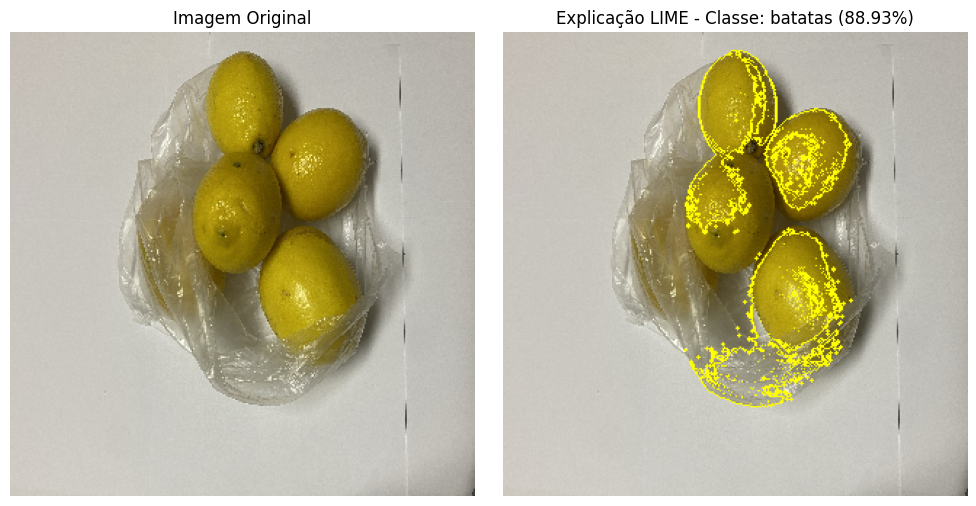

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Função de previsão para o LIME
def predict_fn(images):
    images = np.array(images) / 255.0  # Normalizar as imagens
    return model.predict(images)

# Carregar a imagem de teste
image_path = "/content/dataset/dataset/test/limao/IMG_3495.png"
img = load_img(image_path, target_size=input_size)
img_array = img_to_array(img)

# Inicializar o explicador LIME
explainer = lime_image.LimeImageExplainer()

# Explicar a previsão da imagem
explanation = explainer.explain_instance(img_array.astype('double'),
                                         predict_fn,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Mostrar a explicação para a classe prevista
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=True,
                                            num_features=10,
                                            hide_rest=False)

# Plotar a imagem original e a explicação
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array / 255.0)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"Explicação LIME - Classe: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted class: batatas with confidence: 47.30%


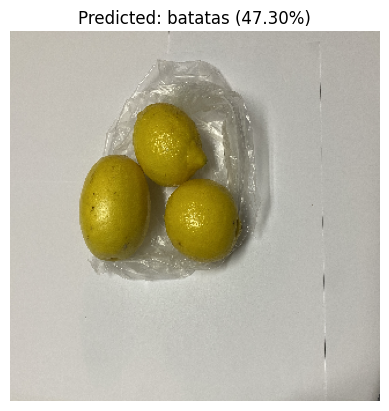

In [ ]:
# caminho da imagem
image_path = "/content/dataset/dataset/test/limao/IMG_3489.png"
input_size = (320, 320)  # tamanho da imagem, o mesmo que o da entrada do modelo

# carregar a imagem e alterar as suas dimensões
img = load_img(image_path, target_size=input_size)

# normalizar a imagem
img_array = img_to_array(img) / 255.0

# adicionar batch dimension
img_array = np.expand_dims(img_array, axis=0)

# previsão
predictions = model.predict(img_array)

# classe prevista
predicted_class_idx = np.argmax(predictions, axis=1)[0]
predicted_class = class_names[predicted_class_idx]
confidence = predictions[0][predicted_class_idx]

# resultados
print(f"Predicted class: {predicted_class} with confidence: {confidence * 100:.2f}%")

#mostrar imagem
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
plt.axis("off")
plt.show()
